<a href="https://colab.research.google.com/github/Wdwood12/Data620_Web_Analytic/blob/main/Mental_Health__Corpus_%E2%80%93_Zipf_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Woodelyne Durosier

Week Eight - Assignment High Frequency Words

03/29/2026

**Load Dataset**

In [13]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("reihanenamdari/mental-health-corpus")

# Load file
file_path = os.path.join(path, "mental_health.csv")
df = pd.read_csv(file_path)

df.head()

Using Colab cache for faster access to the 'mental-health-corpus' dataset.


,text,label
0,dear american teens question dutch person hear...,0
1,nothing look forward lifei dont many reasons k...,1
2,music recommendations im looking expand playli...,0
3,im done trying feel betterthe reason im still ...,1
4,worried year old girl subject domestic physic...,1


**Text Preprocessing**

In [16]:
import nltk
import re

nltk.download('punkt')


# Combine all text into one corpus
text_data = " ".join(df['text'].astype(str))

# Tokenization
tokens = nltk.word_tokenize(text_data)

# clean text
words_clean = [
    w.lower() for w in tokens
    if w.isalpha()
]

print("Total Clean Words:", len(words_clean))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Total Clean Words: 2012454


**Unique Words Count**

In [17]:
unique_words = set(words_clean)
print("Total Unique Words:", len(unique_words))

Total Unique Words: 72230


**Word Frequency Distribution**

In [7]:
from collections import Counter

word_counts = Counter(words_clean)
total_words = sum(word_counts.values())

print("Total Words:", total_words)

Total Words: 2012454


**Words Covering 50% of Corpus**

In [8]:
sorted_words = word_counts.most_common()

cumulative = 0
half_total = total_words / 2
count_50 = 0

for word, freq in sorted_words:
    cumulative += freq
    count_50 += 1
    if cumulative >= half_total:
        break

print("Number of words accounting for 50%:", count_50)

Number of words accounting for 50%: 299


**Top 200 Words**

In [10]:


top_200 = sorted_words[:200]

df_top200 = pd.DataFrame(top_200, columns=['Word', 'Frequency'])
df_top200['Relative Frequency'] = df_top200['Frequency'] / total_words

df_top200.head()

,Word,Frequency,Relative Frequency
0,im,34720,0.017253
1,like,22300,0.011081
2,want,17299,0.008596
3,know,15475,0.007690
4,feel,14508,0.007209


**Relative Frequency Plots**

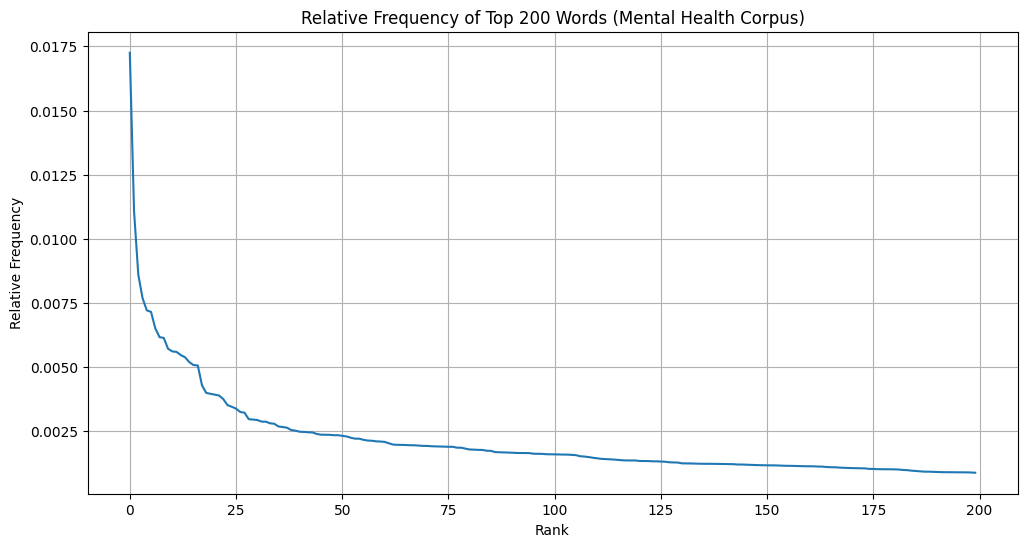

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_top200['Relative Frequency'].values)
plt.title("Relative Frequency of Top 200 Words (Mental Health Corpus)")
plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.grid(True)
plt.show()

**Zipf’s Law (Log-Log Plot)**

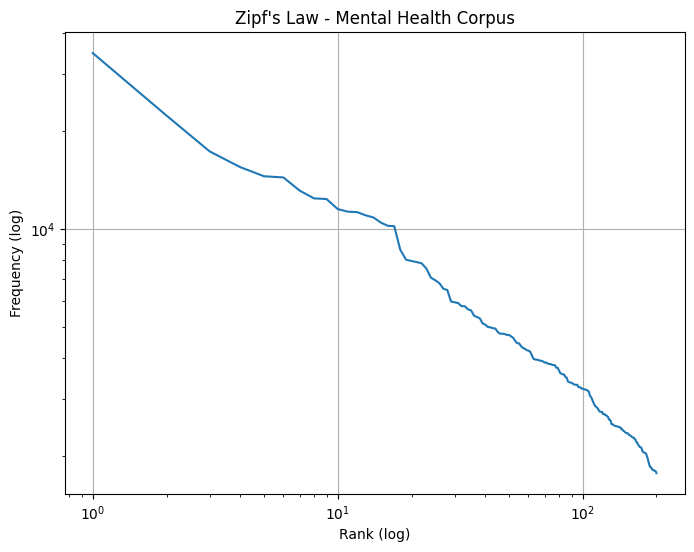

In [12]:
import numpy as np

ranks = np.arange(1, 201)
frequencies = df_top200['Frequency'].values

plt.figure(figsize=(8,6))
plt.loglog(ranks, frequencies)
plt.title("Zipf's Law - Mental Health Corpus")
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.grid(True)
plt.show()

**Remove Stopwords**

In [18]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

words_no_stop = [w for w in words_clean if w not in stop_words]

# Recompute frequencies
word_counts_ns = Counter(words_no_stop)
sorted_words_ns = word_counts_ns.most_common()

top_200_ns = sorted_words_ns[:200]

df_top200_ns = pd.DataFrame(top_200_ns, columns=['Word', 'Frequency'])
df_top200_ns['Relative Frequency'] = df_top200_ns['Frequency'] / sum(word_counts_ns.values())

df_top200_ns.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Word,Frequency,Relative Frequency
0,im,34720,0.018181
1,like,22300,0.011678
2,want,17299,0.009059
3,know,15475,0.008104
4,feel,14508,0.007597


**Unique Words**

The corpus, defined as lowercase alphabetic tokens, contains a large and diverse vocabulary.


**50% Coverage**

50% of the corpus is made up of just 299 words, indicating a high degree of frequency concentration.

**Top Words Insight**

Top words include:

“im”, “like”, “want”, “know”, “feel”

These show:

First-person viewpoint

Expression of emotions


**Zipf’s Law Conclusion**


The corpus complies with Zipf's law, as evidenced by the log-log plot's near-linear connection. A limited number of terms dominate usage whereas the majority of words appear infrequently, and word frequency declines proportionately with rank.


**Differences from General Corpora **

More sentimental and intimate language

Increased usage of first-person pronouns

Domain-specific vocabulary (terms related to mental health)

A less formal framework